## CS 363M: Machine Learning Project
The goal of this project is to predict whether an aircraft wildlife strike resulted in damage to the aircraft (`INDICATED_DAMAGE = 1`) or not (`INDICATED_DAMAGE = 0`).

## Our Approach
Our work is organized as following:
1. Load and inspect the data
2. Identify missing values and data quality issues
3. Drop columns that are too sparse, redundant, or difficult to use meaningfully
4. Clean and impute remaining values
5. Encode categorical variables
6. Train and compare models
7. Evaluate performance and iterate

In [116]:
# Standard Headers
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
from sklearn.model_selection import train_test_split

## Load the Data

We begin by loading the training and test datasets and setting a few common placeholder strings such as `"UNKNOWN"`, `"Unknown"`, and `"UNK"` to missing values. Treating these consistently as null values helps us measure which values are missing more accurately and makes later cleaning steps more reliable.

In [117]:
# Read in the data
train_data = pd.read_csv("data/train.csv", skipinitialspace=True, low_memory=False, na_values = ["UNKNOWN", "Unknown", "UNK"])
test_data = pd.read_csv("data/test.csv", skipinitialspace=True, low_memory=False, na_values=["UNKNOWN", "Unknown", "UNK"])

# Split test data for validation sets
y = train_data["INDICATED_DAMAGE"]
X = train_data.drop(columns=["INDICATED_DAMAGE"])

X_train_raw, X_val_raw, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Save the test ids for later use
test_ids = test_data["INDEX_NR"].copy()

# What percent of data values are null
print("Percent Null:", train_data.isnull().sum().sum() / (len(train_data) * len(train_data.columns)) * 100)

# Null amount for each column
print(train_data.isnull().sum())

Percent Null: 30.561646519429953
INDEX_NR                     0
INCIDENT_DATE                0
INCIDENT_MONTH               0
INCIDENT_YEAR                0
TIME                    132042
TIME_OF_DAY             133971
AIRPORT_ID                   0
AIRPORT                  40684
LATITUDE                 40744
LONGITUDE                40747
RUNWAY                   75586
STATE                    40744
FAAREGION                40744
LOCATION                267965
OPID                     86692
OPERATOR                 86692
REG                     118999
FLT                     161442
AIRCRAFT                 86942
AMA                      88896
AMO                     116813
EMA                     102421
EMO                     113176
AC_CLASS                 87315
AC_MASS                  87446
TYPE_ENG                 87786
NUM_ENGS                 87697
ENG_1_POS                87717
ENG_2_POS               102509
ENG_3_POS               294822
ENG_4_POS               303909
PHASE_

## Data Exploration

For data exploration, we are mainly using plots and examining the data descriptions and visualizations on Kaggle. This section contains our initial plots to gain a deeper understanding of the preexisting relationships in the data. We plot many features against the damage indicatior. Some features did not have clear relationships with the aircraft being damaged, but other features showed clear relationships. We used this information later in our feature engineering to help us decide which features to select and create.

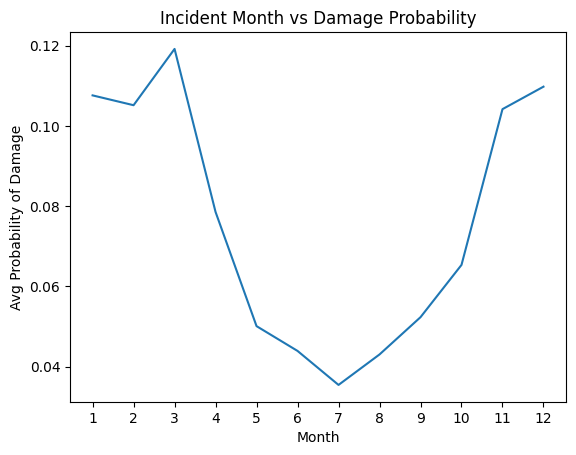

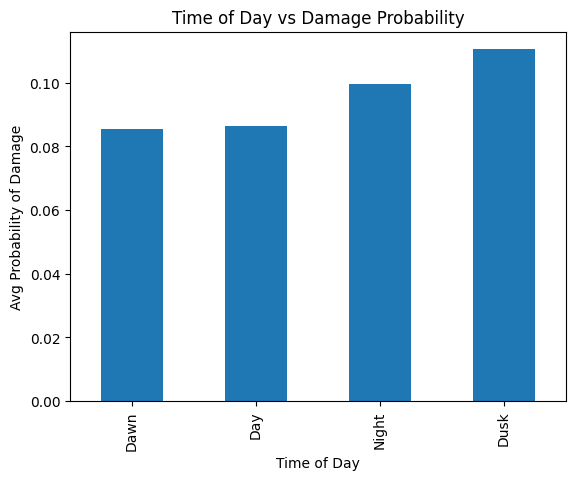

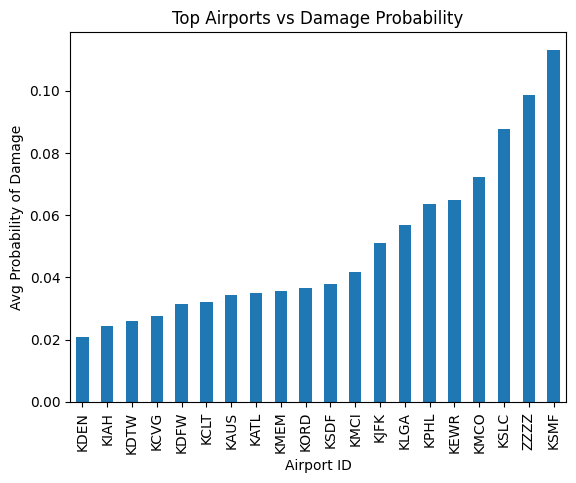

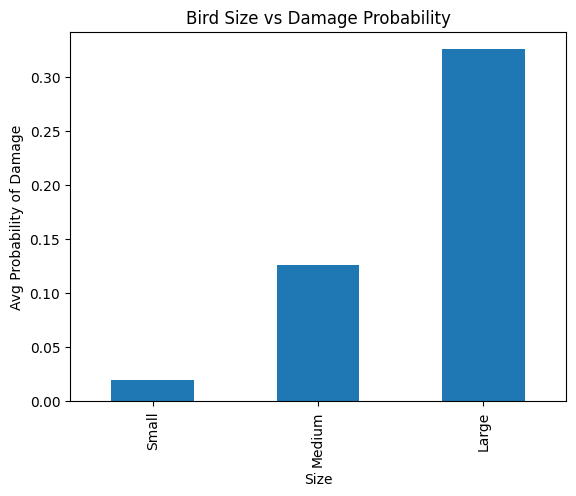

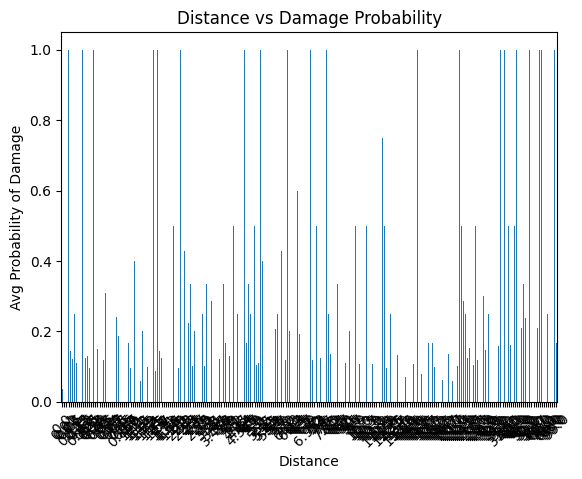

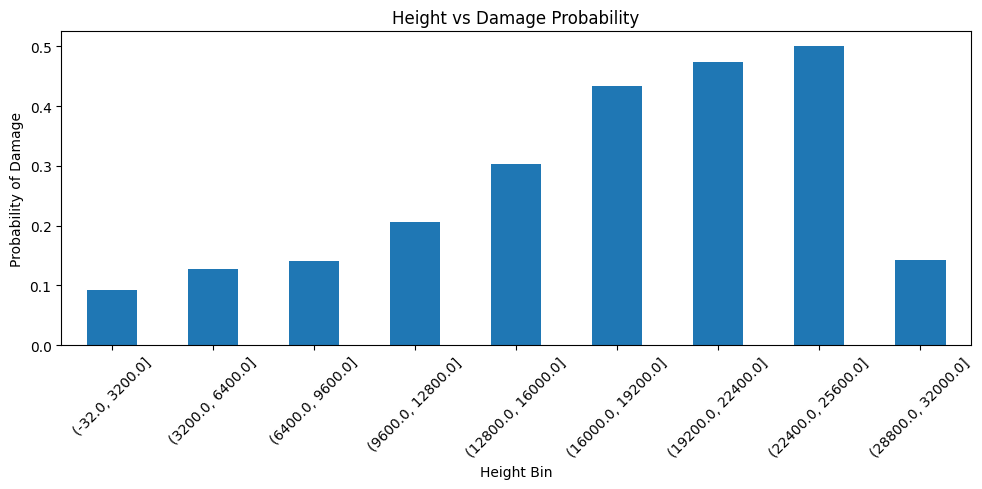

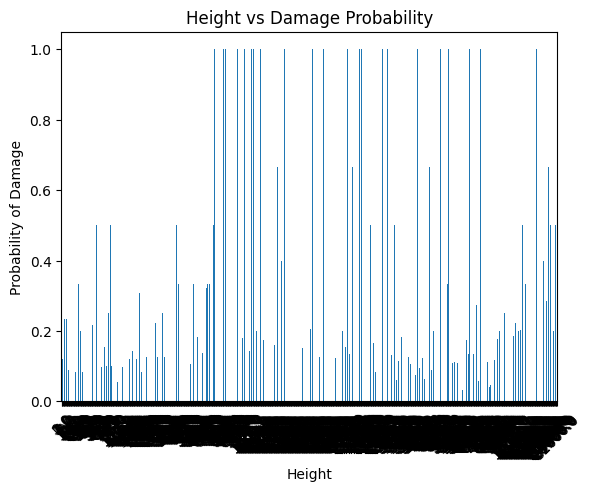

C:\Users\carso\AppData\Local\Temp\ipykernel_16556\3423001123.py:95: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = speed_df.groupby("SPEED_BIN")


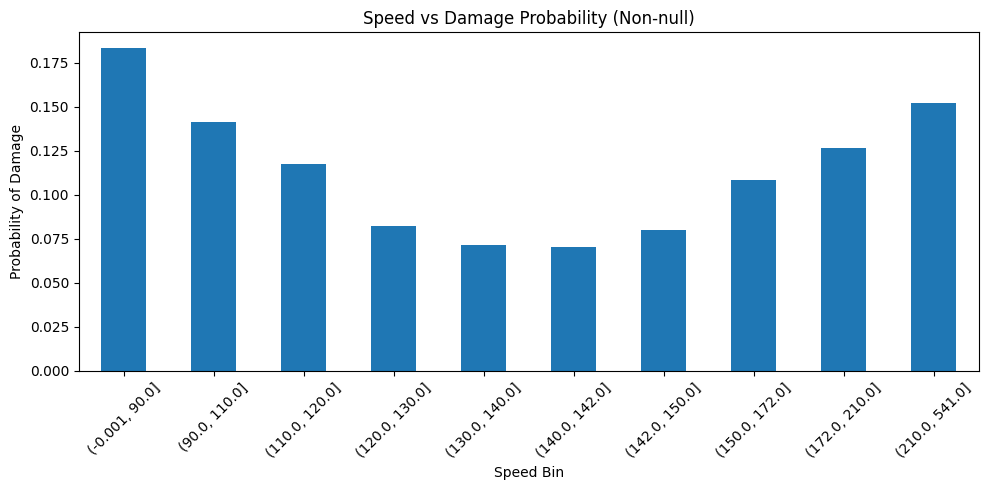

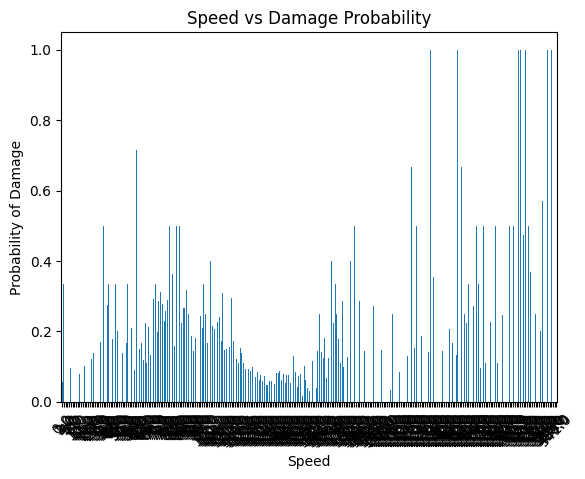

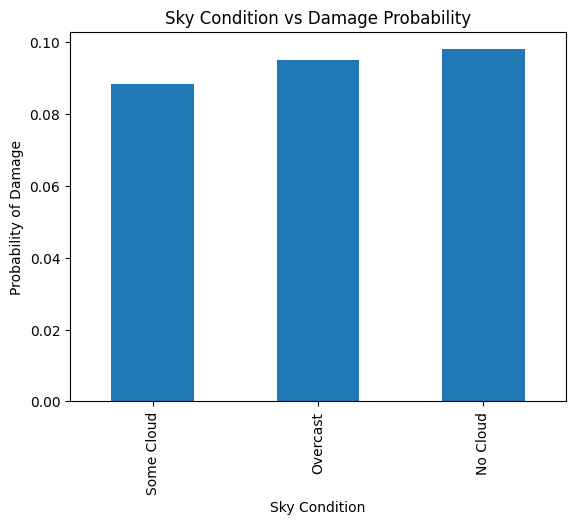

In [162]:
#Plotting "INCIDENT_MONTH" against "INDICATED_DAMAGE"
month_prob = train_data.groupby("INCIDENT_MONTH")["INDICATED_DAMAGE"].mean()
plt.figure()
plt.plot(month_prob.index, month_prob.values)
plt.title("Incident Month vs Damage Probability")
plt.xlabel("Month")
plt.ylabel("Avg Probability of Damage")
plt.xticks(month_prob.index)
plt.show()


#Plotting "TIME_OF_DAY" against "INDICATED_DAMAGE"
time_prob = train_data.groupby("TIME_OF_DAY")["INDICATED_DAMAGE"].mean()
plt.figure()
time_prob.sort_values().plot(kind="bar")
plt.title("Time of Day vs Damage Probability")
plt.xlabel("Time of Day")
plt.ylabel("Avg Probability of Damage")
plt.show()


#Plotting the top 20 "AIRPORT_ID" against "INDICATED_DAMAGE"
top_airports = train_data["AIRPORT_ID"].value_counts().head(20).index
airport_prob = (
    train_data[train_data["AIRPORT_ID"].isin(top_airports)]
    .groupby("AIRPORT_ID")["INDICATED_DAMAGE"]
    .mean()
)
plt.figure()
airport_prob.sort_values().plot(kind="bar")
plt.title("Top Airports vs Damage Probability")
plt.xlabel("Airport ID")
plt.ylabel("Avg Probability of Damage")
plt.show()


#Plotting "SIZE" against "INDICATED_DAMAGE"
size_prob = train_data.groupby("SIZE")["INDICATED_DAMAGE"].mean()
plt.figure()
size_prob.sort_values().plot(kind="bar")
plt.title("Bird Size vs Damage Probability")
plt.xlabel("Size")
plt.ylabel("Avg Probability of Damage")
plt.show()


#Plotting "DISTANCE" against "INDICATED_DAMAGE"
dist_prob = train_data.groupby("DISTANCE")["INDICATED_DAMAGE"].mean()
plt.figure()
dist_prob.plot(kind="bar")
plt.title("Distance vs Damage Probability")
plt.xlabel("Distance")
plt.ylabel("Avg Probability of Damage")
plt.xticks(rotation=45)
plt.show()


#Plotting non-null "HEIGHT" records against "INDICATED_DAMAGE"
height_df = train_data[["HEIGHT", "INDICATED_DAMAGE"]].copy()
height_df = height_df.dropna(subset=["HEIGHT"])

# Bin height
height_df["HEIGHT_BIN"] = pd.cut(height_df["HEIGHT"], bins=10)
height_prob = height_df.groupby("HEIGHT_BIN", observed=True)["INDICATED_DAMAGE"].mean()

plt.figure(figsize=(10, 5))
height_prob.plot(kind="bar")
plt.title("Height vs Damage Probability")
plt.xlabel("Height Bin")
plt.ylabel("Probability of Damage")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#Plotting "HEIGHT" against "INDICATED_DAMAGE"
height_prob = train_data.groupby("HEIGHT")["INDICATED_DAMAGE"].mean()
plt.figure()
height_prob.plot(kind="bar")
plt.title("Height vs Damage Probability")
plt.xlabel("Height")
plt.ylabel("Probability of Damage")
plt.xticks(rotation=45)
plt.show()


#Plotting non-null "SPEED" against "INDICATED_DAMAGE"
speed_df = train_data[["SPEED", "INDICATED_DAMAGE"]].copy()
speed_df = speed_df.dropna(subset=["SPEED"])

# Bin speeds
speed_df["SPEED_BIN"] = pd.qcut(speed_df["SPEED"], q=10, duplicates="drop")

# Compute probability + counts
grouped = speed_df.groupby("SPEED_BIN")
speed_prob = grouped["INDICATED_DAMAGE"].mean()
counts = grouped["INDICATED_DAMAGE"].count()

plt.figure(figsize=(10, 5))
speed_prob.plot(kind="bar")
plt.title("Speed vs Damage Probability (Non-null)")
plt.xlabel("Speed Bin")
plt.ylabel("Probability of Damage")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#Plotting "SPEED" against "INDICATED_DAMAGE"
speed_prob = train_data.groupby("SPEED")["INDICATED_DAMAGE"].mean()
plt.figure()
speed_prob.plot(kind="bar")
plt.title("Speed vs Damage Probability")
plt.xlabel("Speed")
plt.ylabel("Probability of Damage")
plt.xticks(rotation=45)
plt.show()


#Plotting "SKY" against "INDICATED_DAMAGE"
sky_prob = train_data.groupby("SKY")["INDICATED_DAMAGE"].mean()
plt.figure()
sky_prob.sort_values().plot(kind="bar")
plt.title("Sky Condition vs Damage Probability")
plt.xlabel("Sky Condition")
plt.ylabel("Probability of Damage")
plt.show()


## Drop Columns with Excessive Missing Values

Our first cleaning decision is to remove columns that are missing at least 50% of their values. When a feature is mostly empty, it is hard to use reliably without making assumptions during imputation.

We chose this threshold as a way to reduce noise and simplify the feature space. Rather than forcing imputation on extremely sparse columns, we keep the features that contain enough information to be useful.

Dropping a sparse column may remove some signal, but keeping too many incomplete variables can also hurt model quality and make the pipeline harder to interpret.

In [118]:
def get_sparse_cols(df):
    sparse_cols = []

    for col in df.columns:
        if df[col].isnull().sum() >= len(df) / 2:
            if col != "SPEED":
                sparse_cols.append(col)

    return sparse_cols

def drop_sparse_cols(df, sparse_cols):
    df = df.copy()

    # For each column, drop the column if it has 50% or more of its data missing
    print("Before:", len(df.columns))

    for col in sparse_cols:
        if col in df.columns:
            df.drop(col, inplace=True, axis=1)
            print("Dropped:", col)

    print("After:", len(df.columns))
    return df

In [119]:
sparse_cols = get_sparse_cols(X_train_raw)

print("Dropping sparse columns for train data")
X_train_raw = drop_sparse_cols(X_train_raw, sparse_cols)
X_val_raw = drop_sparse_cols(X_val_raw, sparse_cols)

print("\nDropping sparse columns for test data")
test_data = drop_sparse_cols(test_data, sparse_cols)

Dropping sparse columns for train data
Before: 54
Dropped: LOCATION
Dropped: FLT
Dropped: ENG_3_POS
Dropped: ENG_4_POS
Dropped: HEIGHT
Dropped: SKY
Dropped: PRECIPITATION
Dropped: BIRD_BAND_NUMBER
Dropped: WARNED
Dropped: NUM_SEEN
Dropped: ENROUTE_STATE
After: 43
Before: 54
Dropped: LOCATION
Dropped: FLT
Dropped: ENG_3_POS
Dropped: ENG_4_POS
Dropped: HEIGHT
Dropped: SKY
Dropped: PRECIPITATION
Dropped: BIRD_BAND_NUMBER
Dropped: WARNED
Dropped: NUM_SEEN
Dropped: ENROUTE_STATE
After: 43

Dropping sparse columns for test data
Before: 54
Dropped: LOCATION
Dropped: FLT
Dropped: ENG_3_POS
Dropped: ENG_4_POS
Dropped: HEIGHT
Dropped: SKY
Dropped: PRECIPITATION
Dropped: BIRD_BAND_NUMBER
Dropped: WARNED
Dropped: NUM_SEEN
Dropped: ENROUTE_STATE
After: 43


## Remove Redundant or Overlapping Features

Next, we remove several columns that appear to overlap heavily with other features we plan to keep. For example, some text columns have other equivalents, and some location fields overlap with latitude and longitude.

Such as:
- `AIRPORT` overlaps with `AIRPORT_ID` / coordinates
- `OPERATOR` overlaps with `OPID`
- `SPECIES` overlaps with `SPECIES_ID`

Our goal is to reduce redundancy and avoid giving the model multiple versions of the same information.

In [120]:
def drop_redundant_cols(df):
    df = df.copy()

    print("Before:", len(df.columns))

    for col in ["AIRPORT", "OPERATOR", "SPECIES"]:
        if col in df.columns:
            df.drop(col, inplace=True, axis=1)

    print("After:", len(df.columns))
    return df

In [121]:
print("Dropping redundant columns for train data")
X_train_raw = drop_redundant_cols(X_train_raw)
X_val_raw = drop_redundant_cols(X_val_raw)

print("\nDropping redundant columns for test data")
test_data = drop_redundant_cols(test_data)

Dropping redundant columns for train data
Before: 43
After: 40
Before: 43
After: 40

Dropping redundant columns for test data
Before: 43
After: 40


## Drop columns that are difficult to use or not likely to generalize well

In addition to sparse/redundant columns, we also remove a set of features that are less useful for modeling. These include:
- free-text fields
- identifiers
- administrative metadata
- columns with very limited variation
- columns that are difficult to generalize in a simple model

In [122]:
def drop_selected_cols(df):
    df = df.copy()
    
    print("Before:", len(df.columns))

    DROP_COLS = [
        "REMARKS", "REMAINS_SENT", "COMMENTS", "SOURCE", 
        "PERSON", "LUPDATE", "TRANSFER", "NUM_STRUCK", 
        "FAAREGION", "INCIDENT_DATE", "REG", "INDEX_NR", 
        "ENG_1_POS", "ENG_2_POS", "AIRCRAFT", "AMA", 
        "AMO", "EMA", "EMO", "AC_CLASS"
    ]

    for col in DROP_COLS:
        if col in df.columns:
            df.drop(col, inplace=True, axis=1)

    print("After:", len(df.columns))
    return df

In [123]:
print("Dropping selected columns for train data")
X_train_raw = drop_selected_cols(X_train_raw)
X_val_raw = drop_selected_cols(X_val_raw)

print("\nDropping selected columns for test data")
test_data = drop_selected_cols(test_data)

Dropping selected columns for train data
Before: 40
After: 20
Before: 40
After: 20

Dropping selected columns for test data
Before: 40
After: 20


## Why we dropped these columns

These decisions were made to keep the feature set interpretable and to reduce noise before modeling.

In [124]:
"""
REMARKS, COMMENTS: 
Additional notes on the incident that would be difficult to quantify within a ML model

REMAINS_SENT, SOURCE, PERSON, LUPDATE, TRANSFER, REG:
Not very predictive of if there was damage to the aircraft

NUM_STRUCK:
89% of the data was the same, and almost all of the rest was corrupted

FAAREGION:
We decided to use LONG and LAT instead

INCIDENT_DATE: 
This is less relevant than other time values that we decided to keep

INDEX_NR: 
This is a separate index and would skew our result if kept

ENG_1_POS, ENG_2_POS, AIRCRAFT, AMA, AMO, EMA, EMO:
Dropped due to a combination of many missing values and a difficulty to generalize this across different aircrafts

AC_CLASS: 
70% of the data is an aircraft, 2 records total are helicopters, rest is unknown. So this is not very helpful
"""

'\nREMARKS, COMMENTS: \nAdditional notes on the incident that would be difficult to quantify within a ML model\n\nREMAINS_SENT, SOURCE, PERSON, LUPDATE, TRANSFER, REG:\nNot very predictive of if there was damage to the aircraft\n\nNUM_STRUCK:\n89% of the data was the same, and almost all of the rest was corrupted\n\nFAAREGION:\nWe decided to use LONG and LAT instead\n\nINCIDENT_DATE: \nThis is less relevant than other time values that we decided to keep\n\nINDEX_NR: \nThis is a separate index and would skew our result if kept\n\nENG_1_POS, ENG_2_POS, AIRCRAFT, AMA, AMO, EMA, EMO:\nDropped due to a combination of many missing values and a difficulty to generalize this across different aircrafts\n\nAC_CLASS: \n70% of the data is an aircraft, 2 records total are helicopters, rest is unknown. So this is not very helpful\n'

## Re-check missing values after removing columns

After dropping the noisiest/sparsest columns, we inspected missing values again. Since the remaining missing values are more manageable, we do imputation based on the type of variable and the context of the data.

In [125]:
print(X_train_raw.isnull().sum()[X_train_raw.isnull().sum() > 0] / len(X_train_raw) * 100)

TIME               43.027240
TIME_OF_DAY        43.588805
LATITUDE           13.249261
LONGITUDE          13.250482
RUNWAY             24.629083
STATE              13.249261
OPID               28.226758
AC_MASS            28.466440
TYPE_ENG           28.576312
NUM_ENGS           28.549861
PHASE_OF_FLIGHT    39.365269
SPEED              69.071221
DISTANCE           33.644635
SIZE               10.897608
dtype: float64


## Cleaning and Imputing Features

Instead of applying one generic fill strategy to everything, we use more targeted methods based on the meaning of each variable.

We did the following:
- correct formatting issues in latitude and longitude
- fill missing geographic values using airport and state information
- convert time into a numeric hour feature and impute missing values using time of day groups
- fill missing distance values using phase of flight
- prepare these features so they can be used more effectively during modeling

In [126]:
def fix_lat_long_format(df):
    df = df.copy()

    # Find the comma errors where latitude and longitude were combined
    comma_errors = df["LATITUDE"].str.contains(",", na=False)
    vals_with_com_errs = df.loc[comma_errors, "LATITUDE"].str.split(",", expand=True)

    # Fix the comma errors
    df.loc[comma_errors, "LATITUDE"] = vals_with_com_errs[0]
    df.loc[comma_errors, "LONGITUDE"] = vals_with_com_errs[1]

    return df

In [127]:
def fill_lat_long(df, fit=True, stats=None):
    df = df.copy()

    # Make LAT and LONG numeric floats
    df["LATITUDE"] = pd.to_numeric(df["LATITUDE"], errors="coerce")
    df["LONGITUDE"] = pd.to_numeric(df["LONGITUDE"], errors="coerce")

    if fit:
        stats = {}

        for col in ["LATITUDE", "LONGITUDE"]:
            stats[col] = {
                "airport": df.groupby("AIRPORT_ID")[col].median(),
                "state": df.groupby("STATE")[col].median(),
                "global": df[col].median()
            }

    # Fill using TRAIN stats
    for col in ["LATITUDE", "LONGITUDE"]:
        df[col] = df[col].fillna(df["AIRPORT_ID"].map(stats[col]["airport"]))
        df[col] = df[col].fillna(df["STATE"].map(stats[col]["state"]))
        df[col] = df[col].fillna(stats[col]["global"])

    df.drop("AIRPORT_ID", inplace=True, axis=1, errors="ignore")
    df.drop("STATE", inplace=True, axis=1, errors="ignore")

    if fit:
        return df, stats
    return df

In [128]:
def clean_time(df, fit=True, stats=None):
    df = df.copy()

    # Extracting out the hour value from the time column
    df["TIME"] = pd.to_datetime(df["TIME"], format="%H:%M", errors="coerce").dt.round("h").dt.hour

    if fit:
        stats = {}
        stats["time_by_period"] = df.groupby("TIME_OF_DAY")["TIME"].median()
        stats["global_time"] = df["TIME"].median()

    # Filling missing TIME values with the median value of it's TIME_OF_DAY
    df["TIME"] = df["TIME"].fillna(df["TIME_OF_DAY"].map(stats["time_by_period"]))

    # Filling rest of missing TIME values with median time
    df["TIME"] = df["TIME"].fillna(stats["global_time"])

    # Drop TIME_OF_DAY column  
    df.drop("TIME_OF_DAY", inplace=True, axis=1, errors="ignore")

    if fit:
        return df, stats
    
    return df

In [129]:
def clean_distance(df, fit=True, stats=None):
    df = df.copy()

    if fit:
        stats = {}
        stats["phase"] = df.groupby("PHASE_OF_FLIGHT")["DISTANCE"].median()
        stats["global"] = df["DISTANCE"].median()

    # Use PHASE_OF_FLIGHT to fill in nans for DISTANCE
    df["DISTANCE"] = df["DISTANCE"].fillna(df["PHASE_OF_FLIGHT"].map(stats["phase"]))

    # Just use median DISTANCE for nans if PHASE_OF_FLIGHT is also missing for this data point
    df["DISTANCE"] = df["DISTANCE"].fillna(stats["global"])

    if fit:
        return df, stats
    
    return df

In [130]:
def clean_speed(df, fit=True, stats=None):
    df = df.copy()

    df["SPEED_MISSING"] = df["SPEED"].isnull().astype(int)

    if fit:
        stats = {}
        stats["phase"] = df.groupby("PHASE_OF_FLIGHT")["SPEED"].median()
        stats["global"] = df["SPEED"].median()

    # Use PHASE_OF_FLIGHT to fill in nans for SPEED
    df["SPEED"] = df["SPEED"].fillna(df["PHASE_OF_FLIGHT"].map(stats["phase"]))

    # Just use median SPEED for nans if PHASE_OF_FLIGHT is also missing for this data point
    df["SPEED"] = df["SPEED"].fillna(stats["global"])

    if fit:
        return df, stats

    return df

In [131]:
def clean_features(df, fit=True, stats=None):
    df = df.copy()
    
    print("Before:", len(df.columns))

    # Fix formatting
    df = fix_lat_long_format(df)

    if fit:
        stats = {}
        df, stats["geo"] = fill_lat_long(df, fit=True)
        df, stats["time"] = clean_time(df, fit=True)
        df, stats["distance"] = clean_distance(df, fit=True)
        df, stats["speed"] = clean_speed(df, fit=True)


    else:
        df = fill_lat_long(df, fit=False, stats=stats["geo"])
        df = clean_time(df, fit=False, stats=stats["time"])
        df = clean_distance(df, fit=False, stats=stats["distance"])
        df = clean_speed(df, fit=False, stats=stats["speed"])

    print("After:", len(df.columns))
    print(df.isnull().sum() / len(df) * 100)

    if fit:
        return df, stats
    
    return df

In [132]:
print("Cleaning features for train data")
X_train_clean, feature_stats = clean_features(X_train_raw, fit=True)
X_val_clean = clean_features(X_val_raw, fit=False, stats=feature_stats)

print("\nCleaning features for test data")
test_data = clean_features(test_data, fit=False, stats=feature_stats)

Cleaning features for train data
Before: 20
After: 18
INCIDENT_MONTH           0.000000
INCIDENT_YEAR            0.000000
TIME                     0.000000
LATITUDE                 0.000000
LONGITUDE                0.000000
RUNWAY                  24.629083
OPID                    28.226758
AC_MASS                 28.466440
TYPE_ENG                28.576312
NUM_ENGS                28.549861
PHASE_OF_FLIGHT         39.365269
SPEED                    0.000000
DISTANCE                 0.000000
SPECIES_ID               0.000000
OUT_OF_RANGE_SPECIES     0.000000
REMAINS_COLLECTED        0.000000
SIZE                    10.897608
SPEED_MISSING            0.000000
dtype: float64
Before: 20
After: 18
INCIDENT_MONTH           0.000000
INCIDENT_YEAR            0.000000
TIME                     0.000000
LATITUDE                 0.000000
LONGITUDE                0.000000
RUNWAY                  24.516570
OPID                    28.203334
AC_MASS                 28.471906
TYPE_ENG                28

Filling remaining missing values

In [133]:
def fill_missing_values(df, fit=True, stats=None, top_ops=None):
    df = df.copy()

    print("Before:", len(df.columns))

    # Convert runway to is or isn't airborne
    df["AIRBORNE"] = df["RUNWAY"].isnull().astype(int)
    df.drop("RUNWAY", inplace=True, axis=1, errors="ignore")

    # Fill in missing SIZE
    df["SIZE"] = df["SIZE"].fillna("UNK")
    df.drop("SPECIES_ID", inplace=True, axis=1, errors="ignore")

    if fit:
        if top_ops is None:
            top_ops = df["OPID"].value_counts().nlargest(10).index

        stats = {
            "num_engs_median": df["NUM_ENGS"].median(),
            "ac_mass_median": df["AC_MASS"].median(),
            "type_eng_mode": df["TYPE_ENG"].mode()[0]
        }

    # Reduce cardinality of OPID
    df["OPID"] = df["OPID"].where(
        df["OPID"].isin(top_ops), "UNK"
    )

    # Add missing values for PHASE_OF_FLIGHT
    df["PHASE_OF_FLIGHT"] = df["PHASE_OF_FLIGHT"].fillna("MISSING")

    # Fill in missing values using TRAIN stats
    df["NUM_ENGS"] = df["NUM_ENGS"].fillna(stats["num_engs_median"])
    df["AC_MASS"] = df["AC_MASS"].fillna(stats["ac_mass_median"])
    df["TYPE_ENG"] = df["TYPE_ENG"].fillna(stats["type_eng_mode"])

    print("After:", len(df.columns))
    print(df.isnull().sum() / len(df) * 100)

    if fit:
        return df, top_ops, stats
    return df

In [134]:
print("Filling missing values for train data")
X_train_filled, top_ops, fill_stats = fill_missing_values(X_train_clean, fit=True)
X_val_filled = fill_missing_values(X_val_clean, fit=False, stats=fill_stats, top_ops=top_ops)

print("\nFilling missing values for test data")
test_data = fill_missing_values(test_data, fit=False, stats=fill_stats, top_ops=top_ops)

Filling missing values for train data
Before: 18
After: 17
INCIDENT_MONTH          0.0
INCIDENT_YEAR           0.0
TIME                    0.0
LATITUDE                0.0
LONGITUDE               0.0
OPID                    0.0
AC_MASS                 0.0
TYPE_ENG                0.0
NUM_ENGS                0.0
PHASE_OF_FLIGHT         0.0
SPEED                   0.0
DISTANCE                0.0
OUT_OF_RANGE_SPECIES    0.0
REMAINS_COLLECTED       0.0
SIZE                    0.0
SPEED_MISSING           0.0
AIRBORNE                0.0
dtype: float64
Before: 18
After: 17
INCIDENT_MONTH          0.0
INCIDENT_YEAR           0.0
TIME                    0.0
LATITUDE                0.0
LONGITUDE               0.0
OPID                    0.0
AC_MASS                 0.0
TYPE_ENG                0.0
NUM_ENGS                0.0
PHASE_OF_FLIGHT         0.0
SPEED                   0.0
DISTANCE                0.0
OUT_OF_RANGE_SPECIES    0.0
REMAINS_COLLECTED       0.0
SIZE                    0.0
SPEED_MIS

## Identify Categorical Features

Before encoding, we identify which remaining columns should be treated as categorical. This matters because machine learning models generally require numeric input, but not all variables should be converted the same way.

In [135]:
def identify_categorical_cols(df):
    categorical_cols = []
    numeric_cols = []

    for col in df.columns:
        # Try converting column to numeric
        converted = pd.to_numeric(df[col], errors='coerce')
        
        # If any portion becomes NaN, it's categorical
        num_na = converted.isnull().sum()
        
        if num_na > 1:
            categorical_cols.append(col)
        else:
            numeric_cols.append(col)

    print("Categorical Columns:")
    print(categorical_cols)

    print("\nNumeric Columns:")
    print(numeric_cols)

    print("\nTypes of the column data:")
    print(df.dtypes)

    return categorical_cols

In [136]:
print("Identifying categorical columns from train data")
categorical_cols = identify_categorical_cols(X_train_filled)

Identifying categorical columns from train data
Categorical Columns:
['OPID', 'TYPE_ENG', 'PHASE_OF_FLIGHT', 'SIZE']

Numeric Columns:
['INCIDENT_MONTH', 'INCIDENT_YEAR', 'TIME', 'LATITUDE', 'LONGITUDE', 'AC_MASS', 'NUM_ENGS', 'SPEED', 'DISTANCE', 'OUT_OF_RANGE_SPECIES', 'REMAINS_COLLECTED', 'SPEED_MISSING', 'AIRBORNE']

Types of the column data:
INCIDENT_MONTH            int64
INCIDENT_YEAR             int64
TIME                    float64
LATITUDE                float64
LONGITUDE               float64
OPID                     object
AC_MASS                 float64
TYPE_ENG                 object
NUM_ENGS                float64
PHASE_OF_FLIGHT          object
SPEED                   float64
DISTANCE                float64
OUT_OF_RANGE_SPECIES      int64
REMAINS_COLLECTED         int64
SIZE                     object
SPEED_MISSING             int64
AIRBORNE                  int64
dtype: object


## Encoding Categorical Features

Initially, we encoded all categorical variables using **one-hot encoding**. This approach is simple and works well for models because it does not create any ordering between categories.

In [137]:
def encode_cols(df, categorical_cols, fit=True, encoders=None):
    df = df.copy()

    if "INDICATED_DAMAGE" in df.columns:
        X = df.drop("INDICATED_DAMAGE", axis=1).copy()
    else:
        X = df.copy()

    print("Number of rows and cols before encoding:", X.shape)

    if fit:
        high_card_cols = []
        low_card_cols = []

        for col in categorical_cols:
            num_unique = X[col].nunique()

            # Threshold: > 10 unique values, high cardinality
            if num_unique > 10:
                high_card_cols.append(col)
            else:
                low_card_cols.append(col)

        print("High-cardinality columns (frequency encode):", high_card_cols)
        print("Low-cardinality columns (one-hot encode):", low_card_cols)

        freq_maps = {}

        # Frequency encode for high-cardinality columns
        for col in high_card_cols:
            freq = X[col].value_counts(normalize=True)
            freq_maps[col] = freq
            X[col] = X[col].map(freq)

        # One-hot encode for low-cardinality columns
        X_encoded = pd.get_dummies(X, columns=low_card_cols, drop_first=False)

        encoders = {
            "high_card_cols": high_card_cols,
            "low_card_cols": low_card_cols,
            "freq_maps": freq_maps,
            "train_cols": X_encoded.columns
        }

        print("Final shape after encoding:", X_encoded.shape)
        return X_encoded, encoders

    else:
        high_card_cols = encoders["high_card_cols"]
        low_card_cols = encoders["low_card_cols"]
        freq_maps = encoders["freq_maps"]
        train_cols = encoders["train_cols"]

        # Frequency encode using train frequencies
        for col in high_card_cols:
            X[col] = X[col].map(freq_maps[col]).fillna(0)

        # One-hot encode
        X_encoded = pd.get_dummies(X, columns=low_card_cols, drop_first=False)

        # Align columns to training columns
        X_encoded = X_encoded.reindex(columns=train_cols, fill_value=0)

        print("Final shape after encoding:", X_encoded.shape)
        return X_encoded

In [138]:
print("Encoding columns for train data")
X_encoded, encoders = encode_cols(X_train_filled, categorical_cols, fit=True)
X_val_encoded = encode_cols(X_val_filled, categorical_cols, fit=False, encoders=encoders)

print("\nEncoding columns for test data")
X_test_encoded = encode_cols(test_data, categorical_cols, fit=False, encoders=encoders)

Encoding columns for train data
Number of rows and cols before encoding: (245742, 17)
High-cardinality columns (frequency encode): ['OPID', 'PHASE_OF_FLIGHT']
Low-cardinality columns (one-hot encode): ['TYPE_ENG', 'SIZE']
Final shape after encoding: (245742, 26)
Number of rows and cols before encoding: (61436, 17)
Final shape after encoding: (61436, 26)

Encoding columns for test data
Number of rows and cols before encoding: (34131, 17)
Final shape after encoding: (34131, 26)


## Neural Nets

In [139]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import balanced_accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Scale the features for the neural network
scaler = StandardScaler()
X_train = scaler.fit_transform(X_encoded)
X_val = scaler.transform(X_val_encoded)

# Build the neural network model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.Recall(), tf.keras.metrics.Precision()]
)

# Compute the class weights to handle class imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=256,
    class_weight=class_weights
)

# Predict probabilities on the validation set
val_probs = model.predict(X_val).flatten()

best_t = None
thresholds = [0.3, 0.4, 0.5, 0.6]
best_score = -1
scores = []

for t in thresholds:
    val_preds = (val_probs > t).astype(int)
    score = balanced_accuracy_score(y_val, val_preds)
    scores.append(score)

    if score > best_score:
        best_score = score
        best_t = t
        
    print(t, score)

c:\Users\carso\tf-env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


{0: np.float64(0.5339431600903877), 1: np.float64(7.865254128792728)}
Epoch 1/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.4698 - precision: 0.1804 - recall: 0.7939 - val_loss: 0.4391 - val_precision: 0.1987 - val_recall: 0.7995
Epoch 2/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.4416 - precision: 0.1972 - recall: 0.7970 - val_loss: 0.4559 - val_precision: 0.1929 - val_recall: 0.8195
Epoch 3/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.4351 - precision: 0.2002 - recall: 0.8016 - val_loss: 0.4371 - val_precision: 0.2051 - val_recall: 0.8044
Epoch 4/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.4312 - precision: 0.2026 - recall: 0.8040 - val_loss: 0.4143 - val_precision: 0.2138 - val_recall: 0.7869
Epoch 5/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.4280 - precision: 0.2035 - recall: 0.8055 - val_loss: 0.4326 - val_precision: 0.2052 - val_recall: 0.8108
Epoch 6/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.4267 - precision: 0.2039 - r

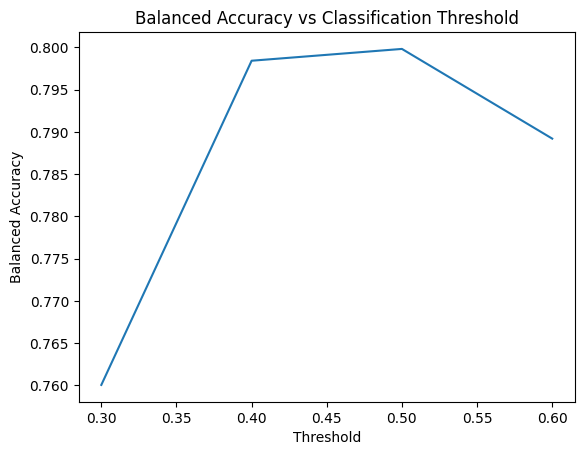

In [140]:
# Plot threshold vs balanced accuracy
plt.plot(thresholds, scores)
plt.xlabel("Threshold")
plt.ylabel("Balanced Accuracy")
plt.title("Balanced Accuracy vs Classification Threshold")
plt.show()

In [141]:
# Scale the Kaggle test data with the SAME scaler fit on X_train
X_test_scaled = scaler.transform(X_test_encoded)

# Predict probabilities on test data
test_probs = model.predict(X_test_scaled)

# Convert probabilities to 0/1 predictions
test_preds = (test_probs > best_t).astype(int)

# Build the submission file
submission = pd.DataFrame({
    "INDEX_NR": test_ids,
    "INDICATED_DAMAGE": test_preds.flatten()
})

submission.to_csv("submission_nn.csv", index=False)

print(submission.head())
print(submission["INDICATED_DAMAGE"].value_counts())

1067/1067 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
   INDEX_NR  INDICATED_DAMAGE
0   9000000                 0
1   9000001                 0
2   9000002                 0
3   9000003                 0
4   9000004                 1
INDICATED_DAMAGE
0    26299
1     7832
Name: count, dtype: int64


## CS 363M: Machine Learning Project Part 2
Our first method worked well and got us an accuracy of around 80%, now we are looking at different methods for cleaning and modeling to see how we can improve that accuracy.

In [142]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

## Load the Data

We begin by loading the training and test datasets. During our initial inspection, we noticed that missing values were recorded inconsistently — some rows used `"UNKNOWN"`, others `"Unknown"` or `"UNK"`. We standardize all of these to `NaN` at load time so that pandas treats them uniformly as missing, which gives us a more accurate picture of data quality before we start cleaning.

In [143]:
# Load data, treating common unknown strings as NaN
train_data = pd.read_csv("data/train.csv", skipinitialspace=True, low_memory=False, na_values=["UNKNOWN", "Unknown", "UNK"])
test_data = pd.read_csv("data/test.csv", skipinitialspace=True, low_memory=False, na_values=["UNKNOWN", "Unknown", "UNK"])

# Save test IDs before we drop the column later
test_ids = test_data["INDEX_NR"].copy()

TARGET = "INDICATED_DAMAGE"

print("Percent Null:", train_data.isnull().sum().sum() / (len(train_data) * len(train_data.columns)) * 100)
print(train_data.isnull().sum())

print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)

Percent Null: 30.561646519429953
INDEX_NR                     0
INCIDENT_DATE                0
INCIDENT_MONTH               0
INCIDENT_YEAR                0
TIME                    132042
TIME_OF_DAY             133971
AIRPORT_ID                   0
AIRPORT                  40684
LATITUDE                 40744
LONGITUDE                40747
RUNWAY                   75586
STATE                    40744
FAAREGION                40744
LOCATION                267965
OPID                     86692
OPERATOR                 86692
REG                     118999
FLT                     161442
AIRCRAFT                 86942
AMA                      88896
AMO                     116813
EMA                     102421
EMO                     113176
AC_CLASS                 87315
AC_MASS                  87446
TYPE_ENG                 87786
NUM_ENGS                 87697
ENG_1_POS                87717
ENG_2_POS               102509
ENG_3_POS               294822
ENG_4_POS               303909
PHASE_

## Initial Data Inspection and Cleaning

After reviewing the columns, we identified several that would not help the model make predictions. Some were administrative fields like `SOURCE` and `PERSON` that describe how the record was filed rather than what happened during the strike. Others like `REMARKS` and `COMMENTS` contain free-text notes that are too unstructured to use directly. `REG` and `FLT` identify a specific aircraft or flight, which makes them too granular to generalize to new data. Finally, `BIRD_BAND_NUMBER` was almost entirely empty since the vast majority of birds involved in strikes are never banded. We drop all of these before moving forward.

In [144]:
def drop_irrelevant_columns(data):
    data = data.copy()
    drop_cols = ["INDEX_NR", "REMARKS", "COMMENTS", "PERSON", "SOURCE", "LUPDATE", "TRANSFER", "BIRD_BAND_NUMBER", "REG", "FLT"]
    
    # Dropping columns
    for col in drop_cols:
        if col in data.columns:
            data = data.drop(columns=[col])
            
    return data

train_data = drop_irrelevant_columns(train_data)
test_data = drop_irrelevant_columns(test_data)

## Feature Engineering

### Date Features

The `INCIDENT_DATE` column stores dates as strings, so we first convert it to a proper datetime format. From there we can extract the year, month, day of week, and quarter. For example, wildlife activity varies significantly by season, so we also create four binary season flags.

In [145]:
def add_date_features(data):
    if "INCIDENT_DATE" not in data.columns:
        return data

    # Convert the string column to an actual datetime type so we can extract parts from it
    dates = pd.to_datetime(data["INCIDENT_DATE"], format="%m/%d/%y", errors="coerce")
    data["quarter"] = dates.dt.quarter

    # Season flags
    data["is_spring"] = data["INCIDENT_MONTH"].isin([3, 4, 5]).astype(int)
    data["is_summer"] = data["INCIDENT_MONTH"].isin([6, 7, 8]).astype(int)
    data["is_fall"] = data["INCIDENT_MONTH"].isin([9, 10, 11]).astype(int)
    data["is_winter"] = data["INCIDENT_MONTH"].isin([12, 1, 2]).astype(int)

    data = data.drop(columns=["INCIDENT_DATE"])
    return data

### Numeric Column Conversion

Several columns that represent numeric quantities (like altitude, speed, and engine position) were stored as mixed-type or string columns in the raw CSV. If we leave them as strings, the model cannot use them numerically. We force each one to a proper numeric type, and any value that cannot be converted becomes `NaN`, which will be handled later by the imputer in our preprocessing pipeline.

In [146]:
def convert_numeric_columns(data):
    # These columns can sometimes be read as strings, so we force them to numbers
    numeric_cols = [
        "HEIGHT", "SPEED", "DISTANCE", "NUM_SEEN", "NUM_STRUCK",
        "AC_MASS", "NUM_ENGS", "LATITUDE", "LONGITUDE",
        "AMA", "AMO", "EMA", "EMO",
        "ENG_1_POS", "ENG_2_POS", "ENG_3_POS", "ENG_4_POS"
    ]
    for col in numeric_cols:
        if col in data.columns:
            data[col] = pd.to_numeric(data[col], errors="coerce")  # non-numeric values become NaN
    return data

### Bird Size Features

The `SIZE` column describes the bird as Small, Medium, or Large, but the raw string label is not directly usable by tree-based models in a meaningful ordinal way. We create an ordinal encoding (1, 2, 3) so the model understands that Large > Medium > Small in terms of potential impact. We also add two binary flags for large and medium birds so the model can learn non-linear relationships for specific size categories independently.

In [147]:
def add_size_features(data):
    if "SIZE" not in data.columns:
        return data

    # Ordinal encoding so the model knows Large > Medium > Small
    size_map = {"Small": 1, "Medium": 2, "Large": 3}
    data["SIZE_ENCODED"] = data["SIZE"].map(size_map)
    data["is_large_bird"] = (data["SIZE"] == "Large").astype(int)
    data["is_medium_bird"] = (data["SIZE"] == "Medium").astype(int)
    
    data = data.drop(columns=["SIZE"])
    return data

### Flight Phase Features

The phase of flight at the time of the strike turned out to be an important signal. Strikes during takeoff, climb, landing roll, and approach tend to be more severe because the aircraft is at lower altitudes, traveling at speeds where evasion is impossible, and the engines are under higher load. We flag each of these individually and also create a combined `is_critical_phase` feature to give the model a single high-level indicator of dangerous conditions.

In [148]:
def add_flight_phase_features(data):
    if "PHASE_OF_FLIGHT" not in data.columns:
        return data

    data["is_takeoff"] = (data["PHASE_OF_FLIGHT"] == "Take-off Run").astype(int)
    data["is_landing"] = data["PHASE_OF_FLIGHT"].isin(["Landing Roll", "Approach"]).astype(int)
    data["is_climb"] = (data["PHASE_OF_FLIGHT"] == "Climb").astype(int)

    # Combined flag for all high-risk phases
    critical_phases = ["Take-off Run", "Landing Roll", "Approach", "Climb"]
    data["is_critical_phase"] = data["PHASE_OF_FLIGHT"].isin(critical_phases).astype(int)
    return data

### Time of Day Features

Strikes that happen at night or during dawn and dusk are more likely to result in damage because pilots have reduced visibility and less time to react. We create binary flags for these low-visibility periods so the model can learn this pattern directly rather than trying to extract it from a raw categorical string.

In [149]:
def add_time_of_day_features(data):
    if "TIME_OF_DAY" not in data.columns:
        return data

    data["is_night"] = (data["TIME_OF_DAY"] == "Night").astype(int)
    data["is_dawn_dusk"] = data["TIME_OF_DAY"].isin(["Dawn", "Dusk"]).astype(int)
    
    data = data.drop(columns=["TIME_OF_DAY"])

    return data

### Speed, Height, and Impact Features

Speed and altitude at the time of the strike are two of the most physically meaningful predictors. A bird struck at high speed carries far more kinetic energy, and strikes at low altitude give the crew no time to respond. We create an interaction term (`speed_height`) that captures the combined effect of both, and a `low_altitude` flag for strikes at or below 500 feet. We also combine speed with bird size to create a proxy for impact force, since a large bird at high speed is a very different scenario than a small bird at low speed.

In [150]:
def add_speed_height_features(data):
    if "HEIGHT" not in data.columns or "SPEED" not in data.columns:
        return data

    data["speed_sq"] = data["SPEED"] * data["SPEED"]
    data["speed_height"] = data["SPEED"] * data["HEIGHT"]
    data["low_altitude"] = (data["HEIGHT"] <= 500).astype(int)

    # Impact risk proxy: faster speed + larger bird = more damage potential
    if "SIZE_ENCODED" in data.columns:
        data["bird_aircraft_risk"] = data["SPEED"] * data["SIZE_ENCODED"]
    return data

### Strike Count Features

The dataset records both how many birds were seen and how many were actually struck. Rather than using these raw counts alone, we compute the ratio of birds struck to birds seen.

In [151]:
def add_strike_count_features(data):
    if "NUM_SEEN" not in data.columns or "NUM_STRUCK" not in data.columns:
        return data

    data["strike_density"] = data["NUM_STRUCK"] / (data["NUM_SEEN"] + 1)
    
    return data

### Aircraft Mass Features

Heavier aircraft are generally more structurally robust, but they also have larger engines that birds can be ingested into. The `AC_MASS` column uses a categorical mass code rather than an exact weight. We flag aircraft in mass category 4 or above as heavy, which roughly corresponds to large commercial jets. This gives the model a simple way to distinguish commercial airliners from smaller regional aircraft.

In [152]:
def add_aircraft_features(data):
    if "AC_MASS" not in data.columns:
        return data

    # Mass category 4+ corresponds to large commercial aircraft
    data["is_heavy_aircraft"] = (data["AC_MASS"] >= 4).astype(int)
    return data

### Weather Features

Adverse weather conditions can affect both the likelihood and severity of a strike. Rain or other precipitation reduces visibility, and overcast skies can push birds lower where aircraft traffic is heavier. We create a `has_precip` flag by checking whether the precipitation field has a real recorded value.

In [153]:
def add_weather_features(data):
    if "PRECIPITATION" in data.columns:
        has_value = data["PRECIPITATION"].notna()
        no_precip_labels = ["None", "No", "Missing"]
        is_not_none = data["PRECIPITATION"].isin(no_precip_labels) == False
        data["has_precip"] = (has_value & is_not_none).astype(int)

    if "SKY" in data.columns:
        data["is_overcast"] = (data["SKY"] == "Overcast").astype(int)
        data["has_clouds"] = data["SKY"].isin(["Some Cloud", "Overcast"]).astype(int)

    data = data.drop(columns=["PRECIPITATION"])
    data = data.drop(columns=["SKY"])


    return data

### Species Features

The species name is a free-text field with hundreds of distinct values, so too many to one-hot encode directly. Instead, we group species into risk categories based on keywords in the name. Raptors and large waterfowl like geese tend to cause more damage due to their size and flight patterns. Small songbirds are generally lower risk.

In [154]:
def species_contains_any(species_series, keywords):
    # Start with all zeros, then set 1 wherever any keyword matches
    result = pd.Series([0] * len(species_series), index=species_series.index)
    for keyword in keywords:
        result[species_series.str.contains(keyword)] = 1
    return result


def add_species_features(data):
    if "SPECIES" not in data.columns:
        return data

    species = data["SPECIES"].fillna("").str.lower()

    raptor_keywords = ["hawk", "eagle", "falcon", "kestrel", "osprey", "owl", "vulture"]
    data["is_raptor"] = species_contains_any(species, raptor_keywords)

    water_bird_keywords = ["gull", "goose", "duck", "heron", "egret", "crane", "pelican", "cormorant"]
    data["is_water_bird"] = species_contains_any(species, water_bird_keywords)

    data["is_unknown_bird"] = species_contains_any(species, ["unknown"])

    songbird_keywords = ["swallow", "sparrow", "starling", "lark", "dove", "pigeon"]
    data["is_small_songbird"] = species_contains_any(species, songbird_keywords)

    large_bird_keywords = ["hawk", "eagle", "vulture", "goose", "pelican"]
    data["is_large_bird_group"] = species_contains_any(species, large_bird_keywords)

    data = data.drop(columns=["SPECIES"])


    return data

### Warning Features

The `WARNED` column records whether the flight crew received a warning about wildlife before the strike. We suspected that a warning with no resulting avoidance might correlate with more severe outcomes, and that an unwarned strike might reflect a surprise collision. We encode both the yes and no cases as separate binary features so the model can distinguish them from missing values, which indicate the information was simply not recorded.

In [155]:
def add_warned_features(data):
    if "WARNED" not in data.columns:
        return data

    data["warned_yes"] = (data["WARNED"] == "Yes").astype(int)
    data["warned_no"] = (data["WARNED"] == "No").astype(int)
    
    data = data.drop(columns=["WARNED"])

    return data

### Missing Values Indicators

There are many columns in the data that have a high number of missing data points, but we found through data exploration that a row having missing values can be predictive for certain columns. This function acklowledges those correlations by adding columns for those scenarios.

In [156]:
def add_missing_indicators(data):
    important_cols = [
        "SPEED", "HEIGHT", "DISTANCE",
        "NUM_SEEN", "NUM_STRUCK"
    ]

    for col in important_cols:
        if col in data.columns:
            data[f"{col}_missing"] = data[col].isna().astype(int)

    return data

### Running Feature Engineering

With all helper functions defined, `make_features` acts as the single entry point that runs each transformation in sequence. We apply it to both the train and test sets so that both end up with the same feature columns.

In [157]:
def make_features(data):
    data = data.copy()

    data = add_date_features(data)
    data = convert_numeric_columns(data)
    data = add_size_features(data)
    data = add_flight_phase_features(data)
    data = add_time_of_day_features(data)
    data = add_speed_height_features(data)
    data = add_strike_count_features(data)
    data = add_aircraft_features(data)
    data = add_weather_features(data)
    data = add_species_features(data)
    data = add_warned_features(data)
    data = add_missing_indicators(data)

    return data


train_fe = make_features(train_data)
test_fe = make_features(test_data)

## Model Pipeline and Training

With our features ready, we set up the preprocessing pipeline and train two models: XGBoost and LightGBM. Both are gradient boosting algorithms that handle tabular data well. We use a `ColumnTransformer` to apply different preprocessing to numeric and categorical columns — median imputation for numeric, mode imputation plus one-hot encoding for categorical. Rare category values (appearing fewer than 15 times) are dropped from the one-hot encoding to avoid overfitting on noise.

Because damage cases are less common than non-damage cases, we also pass a class imbalance weight to each model so it does not simply learn to predict "no damage" for everything. We then use 5-fold stratified cross-validation and collect out-of-fold predictions, which lets us blend and evaluate the models honestly without touching the test set.

In [158]:
y = train_fe[TARGET].astype(int)
X = train_fe.drop(columns=[TARGET])

# Align test set to the same columns as train
test_fe = test_fe.reindex(columns=X.columns, fill_value=np.nan)

numeric_cols = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()

numeric_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])

categorical_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")),
                                          ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=15))])

preprocessor = ColumnTransformer(transformers=[("num", numeric_transformer, numeric_cols), ("cat", categorical_transformer, categorical_cols)], remainder="drop")

spw = (y == 0).sum() / (y == 1).sum()

xgb_clf = XGBClassifier(
    n_estimators=900,
    max_depth=7,
    learning_rate=0.03,
    subsample=0.90,
    colsample_bytree=0.80,
    min_child_weight=3,
    gamma=0.15,
    reg_alpha=0.25,
    reg_lambda=1.25,
    scale_pos_weight=spw,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

lgb_clf = LGBMClassifier(
    n_estimators=900,
    learning_rate=0.03,
    num_leaves=64,
    max_depth=8,
    min_child_samples=20,
    subsample=0.90,
    colsample_bytree=0.80,
    reg_alpha=0.25,
    reg_lambda=1.25,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

models = [("xgb", Pipeline(steps=[("preprocess", preprocessor), ("model", xgb_clf)])), 
          ("lgb", Pipeline(steps=[("preprocess", preprocessor), ("model", lgb_clf)]))]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof = np.zeros((len(X), len(models)))
test_proba = np.zeros((len(test_fe), len(models)))

for model_index, (name, model) in enumerate(models):
    print(f"\nTraining {name}")
    fold_test_probs = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_train_fold = X.iloc[train_idx]
        X_val_fold = X.iloc[val_idx]
        y_train_fold = y.iloc[train_idx]
        y_val_fold = y.iloc[val_idx]

        model.fit(X_train_fold, y_train_fold)

        val_probs = model.predict_proba(X_val_fold)[:, 1]
        test_probs = model.predict_proba(test_fe)[:, 1]

        oof[val_idx, model_index] = val_probs
        fold_test_probs.append(test_probs)

        fold_score = balanced_accuracy_score(y_val_fold, (val_probs >= 0.5).astype(int))
        print(f"  Fold {fold + 1}: {fold_score:.4f}")

    # Average test predictions across all folds for a more stable estimate
    test_proba[:, model_index] = np.mean(fold_test_probs, axis=0)


Training xgb
  Fold 1: 0.8290
  Fold 2: 0.8203
  Fold 3: 0.8232
  Fold 4: 0.8232
  Fold 5: 0.8316

Training lgb


c:\Users\carso\tf-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\carso\tf-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Fold 1: 0.8285


c:\Users\carso\tf-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\carso\tf-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Fold 2: 0.8200


...

c:\Users\carso\tf-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\carso\tf-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Fold 4: 0.8228


c:\Users\carso\tf-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Fold 5: 0.8314


c:\Users\carso\tf-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Optimization

Rather than treating both models equally, we search for the best blend weight between XGBoost and LightGBM using their out-of-fold predictions. At the same time, we search for the best probability threshold for classifying a strike as damaging. The default threshold of 0.5 is rarely optimal on imbalanced datasets — tuning it on the OOF predictions lets us improve balanced accuracy without touching the test set.

In [159]:
best_score = 0
best_weight = 0.5
best_thresh = 0.5

for w in np.arange(0.0, 1.01, 0.05):
    blended_oof = w * oof[:, 0] + (1 - w) * oof[:, 1]

    for t in np.arange(0.10, 0.90, 0.01):
        predictions = (blended_oof >= t).astype(int)
        score = balanced_accuracy_score(y, predictions)

        if score > best_score:
            best_score = score
            best_thresh = t
            best_weight = w

print(f"Best OOF Balanced Accuracy: {best_score:.4f}")
print(f"Best threshold: {best_thresh:.2f}")
print(f"Best XGB weight: {best_weight:.2f}")

Best OOF Balanced Accuracy: 0.8271
Best threshold: 0.45
Best XGB weight: 0.70


## Final Prediction

Using our optimized parameters, we generated the final predictions for the test set. This ensemble approach provides a more robust and accurate prediction than our initial baseline.

In [161]:
final_proba = best_weight * test_proba[:, 0] + (1 - best_weight) * test_proba[:, 1]
final_preds = (final_proba >= best_thresh).astype(int)

submission = pd.DataFrame({"INDEX_NR": test_ids.values, "INDICATED_DAMAGE": final_preds})

submission.to_csv("submission.csv", index=False)

print("Final submission created successfully.")

Final submission created successfully.
